<a href="https://colab.research.google.com/github/LuisFelipeCSouza/inteligencia-computacional-aplicada/blob/main/notebooks/trabalho-1.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
BASE_DIR = Path('..').parent.resolve().parent
DATA_DIR = BASE_DIR / 'data' / 'Gauss3.csv'

In [3]:
# data = np.loadtxt(DATA_DIR, skiprows=59, max_rows=11, usecols=(0, 1), unpack=True)
data = np.genfromtxt(DATA_DIR, skip_header=1)
data
X = data[:, [1]]
y = data[:, [0]]

## Modelo Polinomial de ordem k.

In [4]:
class PolynomialRegression:
    def __init__(self, degree):
        self.degree = degree
        self.coefficients = None

    def fit(self, X, y):

        X_poly = self._polymonil_features(X, self.degree)
        # self.coefficients = np.linalg.lstsq(X_poly, y, rcond=None)[0]
        self.coefficients = np.linalg.solve(X_poly.T @ X_poly, X_poly.T @ y)

    def predict(self, X):
        X_poly = self._polymonil_features(X, self.degree)
        return X_poly @ self.coefficients

    def _polymonil_features(self, X, degree):
        m, n = X.shape
        X_poly = np.ones((m, 1))
        for i in range(n):
            x = X[:, i]
            X_poly = np.c_[X_poly, np.vander(x, degree +1, increasing=True)[:, 1:]]
        return X_poly

## Modelo Linear por partes

In [5]:
class PiecewiseLinearRegression:
    def __init__(self, n_pieces=None, knots=None):
        self.n_pieces = n_pieces
        self.knots = knots
        self.coefficients = None

    def fit(self, X, y):

        X_basis_expanded = self._basis_functions(X)

        self.coefficients = np.linalg.solve(X_basis_expanded.T @ X_basis_expanded, X_basis_expanded.T @ y)

    def predict(self, X):

        X_basis_expanded = self._basis_functions(X)

        return X_basis_expanded @ self.coefficients
    
    def _basis_functions(self, X):
        return np.hstack(
        [
        np.ones(X.shape),
        X,

        *[np.maximum(X - kl, 0) for kl in self.knots],
        ]
        )


## Modelo Fuzzy do tipo Mamdani

In [6]:
class MamdaniFuzzy:
        
    def __init__(self, centers, spread, singleton_outputs):
        self.centers = np.array(centers)
        self.spread = spread
        self.outputs = np.array(singleton_outputs)
        
    def _gaussian_mf(self, x, c, sigma):
        return np.exp(-((x - c) ** 2) / (2 * sigma ** 2))
    
    def predict(self, X):
        X = np.asarray(X)
        y_pred = []
        
        # Iterando sobre cada amostra de entrada
        for j in range(len(X)):
            # As ativações (mi) das regras são os valores de pertinência da velocidade (Passo 6)
            mi = self._gaussian_mf(float(X[j][0]), self.centers, self.spread)
            
            # A saída predita é a média ponderada das potências de saídas das regras (Eq 12, 13, 14)
            y_pred.append(np.sum(mi * self.outputs) / np.sum(mi))
            
        return np.array(y_pred)
    
    def r2_score(self, y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        
        # Valor médio da potência 
        y_mean = np.mean(y_true)
        
        # Erro de predição do modelo Mamdani (Numerador)
        ss_res = np.sum((y_true - y_pred) ** 2)
        
        # Erro do modelo de predição pela média (Denominador)
        ss_tot = np.sum((y_true - y_mean) ** 2)
        
        # Índice R2
        r2 = 1 - (ss_res / ss_tot)
        return r2

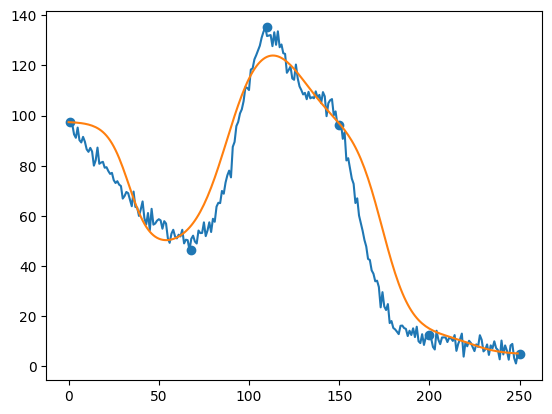

In [112]:

centros = [1, 68, 110, 150, 200, 250]
potencias_saida = [97.58, 46.44, 135.12, 96.44, 12.42, 4.87]
raio = 1.35                             # spread [cite: 51]
raio = 20

# Instanciando o modelo
modelo_fuzzy = MamdaniFuzzy(centers=centros, spread=raio, singleton_outputs=potencias_saida)

y_pred = modelo_fuzzy.predict(X)
y_pred

plt.plot(y)
plt.plot(y_pred)
plt.scatter(centros, potencias_saida)



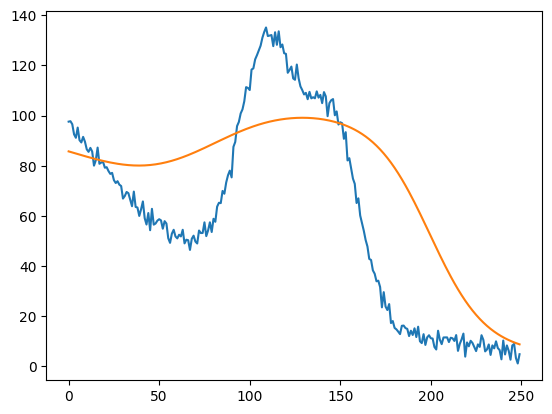

In [84]:
y_pred = modelo_fuzzy.predict(X)
y_pred

plt.plot(y)
plt.plot(y_pred)


## Modelo Fuzzy do tipo Katagi-Sugeno

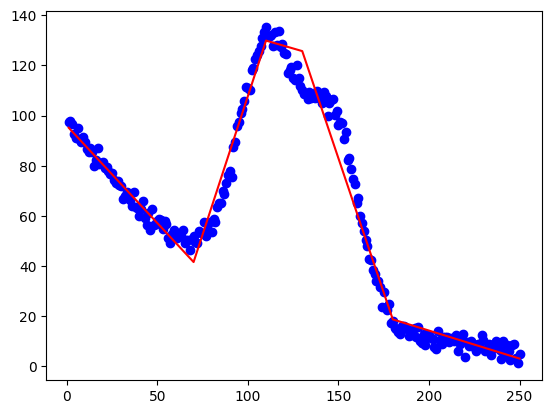

In [ ]:
pwreg = PiecewiseLinearRegression(knots=[70, 110, 130, 180])
pwreg.fit(X, y)
y_pred = pwreg.predict(X)

plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, y_pred, color='red', label='Piecewise Linear Fit')

In [11]:
def predition(X, y, degree):
    
    reg = PolynomialRegression(degree)
    reg.fit(X, y)
    return reg.predict(X)

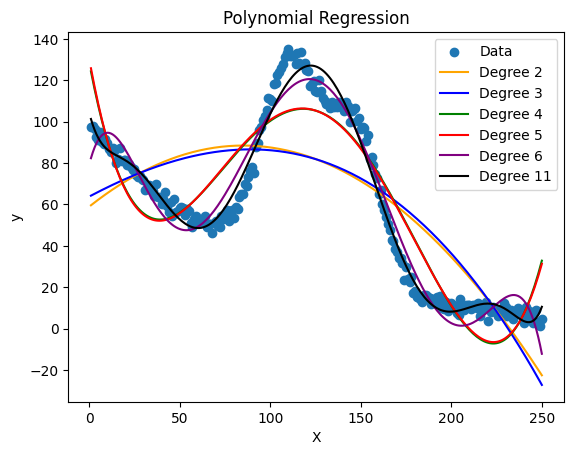

In [12]:
y_pred_2 = predition(X, y, degree=2)
y_pred_3 = predition(X, y, degree=3)
y_pred_4 = predition(X, y, degree=4)
y_pred_5 = predition(X, y, degree=5)
y_pred_6 = predition(X, y, degree=6)
y_pred_11 = predition(X, y, degree=8)
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred_2, label='Degree 2', color='orange')
plt.plot(X, y_pred_3, label='Degree 3', color='blue')
plt.plot(X, y_pred_4, label='Degree 4', color='green')
plt.plot(X, y_pred_5, label='Degree 5', color='red')
plt.plot(X, y_pred_6, label='Degree 6', color='purple')
plt.plot(X, y_pred_11, label='Degree 11', color='black')


plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression')
plt.legend()
plt.show()


## Carregando arquivo

In [16]:
# data = np.loadtxt(DATA_DIR, skiprows=59, max_rows=11, usecols=(0, 1), unpack=True)
data = np.genfromtxt(DATA_DIR, skip_header=1)
data
X = data[:, [1]]
y = data[:, [0]]

X.shape

(250, 1)

## Aplicação

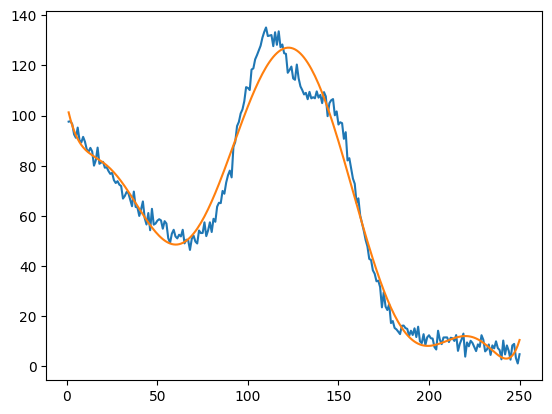

In [25]:
polyreg = PolynomialRegression(degree=8)

polyreg.fit(X=X, y=y)

y_pred = polyreg.predict(X=X)

plt.plot(X, y)
plt.plot(X, y_pred)

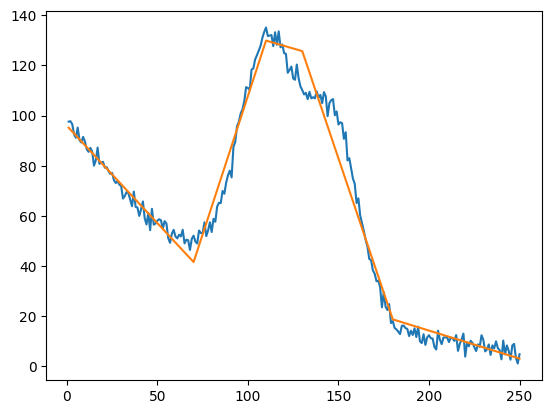

In [26]:
pwreg = PiecewiseLinearRegression(knots=[70, 110, 130, 180])

pwreg.fit(X=X, y=y)

y_pred = pwreg.predict(X=X)

plt.plot(X, y)
plt.plot(X, y_pred)

In [1]:
class GridSearch:
    def __init__(self):
        pass